# Au verification: multislice vs WPM vs ODE

Thicknes sweep for Au comparing abTEM multislice, WPM, and an adaptive ODE integrator.

In [1]:
%matplotlib inline

import os
from time import perf_counter

# Limit CPU threads so we leave cores for others.
# N_THREADS = "32"  # out of 128 available
# os.environ["OMP_NUM_THREADS"] = N_THREADS
# os.environ["MKL_NUM_THREADS"] = N_THREADS
# os.environ["OPENBLAS_NUM_THREADS"] = N_THREADS
# os.environ["NUMBA_NUM_THREADS"] = N_THREADS
# os.environ["XLA_FLAGS"] = f"--xla_cpu_global_thread_pool_size={N_THREADS}"
# The forward KG/Bloch verification cell uses a much finer z-discretization and
# needs a substantially larger JAX GPU memory budget than the early notebook version.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

# # Point CuPy/NVRTC to CUDA toolkit.
# os.environ["CUDA_PATH"] = "/usr/local/cuda-12.6"
# os.environ["CUDA_HOME"] = "/usr/local/cuda-12.6"

import abtem
import cupy
import cupy.cuda.compiler as cupy_compiler
from scipy.interpolate import interp1d

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from tqdm.auto import tqdm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_kg_ode_full,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    get_abtem_transmit,
)
from wide_angle_propagation.propagation_methods import (
    beam_amplitudes_fwd_direct_allbeams,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


def beam_amplitude_normalized(psi_xy, h, k, use_fftshift=True):
    Ny, Nx = psi_xy.shape
    C = np.fft.fft2(psi_xy) / (Nx * Ny)
    if use_fftshift:
        C = np.fft.fftshift(C)
        cy, cx = Ny // 2, Nx // 2
        return np.abs(C[cy + k, cx + h])
    else:
        return np.abs(C[k % Ny, h % Nx])

Extracted data from Klein-Gordon equation solutions for both diagrams a and b of figure 3 in doi:10.1016/j.ultramic.2008.08.008

In [2]:

# Extracted Plot data:

raw_data_Au_Beam_0_0_Klein_Gordon_MS = """0.06421232876712413, 0.9984732824427482
0.98458904109589, 0.9874045801526719
1.9049657534246576, 0.9599236641221375
2.397260273972603, 0.9431297709923665
3.4460616438356153, 0.9041984732824428
4.216609589041096, 0.8809160305343512
4.880136986301369, 0.867557251908397
5.736301369863013, 0.8641221374045802
6.6138698630137, 0.8725190839694656
7.4486301369863, 0.8858778625954199
8.197773972602743, 0.9022900763358779
8.94691780821918, 0.918320610687023
9.76027397260274, 0.9286259541984734
10.637842465753426, 0.9324427480916031
11.665239726027401, 0.9240458015267177
12.671232876712331, 0.9041984732824428
13.613013698630137, 0.8809160305343513
14.511986301369863, 0.8595419847328245
15.325342465753433, 0.8450381679389314
16.438356164383563, 0.835496183206107
17.529965753424662, 0.8381679389312977
18.728595890410965, 0.8461832061068704
19.58476027397261, 0.8515267175572521
20.71917808219178, 0.8530534351145038
21.72517123287672, 0.8473282442748091
23.073630136986306, 0.8297709923664123
24.14383561643836, 0.8118320610687024
24.807363013698637, 0.8030534351145039

"""


raw_data_Au_Beam_0_28_Klein_Gordon_FWD = """0.22062721060899548, 0.00022950819672130918
0.7942772332571906, 0.000852459016393449
1.500467420321705, 0.0018360655737704942
2.339342334788604, 0.0033770491803278707
3.0016335617428496, 0.004622950819672133
4.680202580931187, 0.008819672131147538
5.828562754792266, 0.011508196721311474
7.373218261196406, 0.013475409836065575
8.475824249959047, 0.013901639344262293
9.798479197386307, 0.013770491803278686
10.768593209394673, 0.013901639344262293
11.915700504042945, 0.014885245901639345
12.908872312333159, 0.01639344262295082
14.41020711057142, 0.01940983606557377
15.05035610682242, 0.020524590163934424
16.373974807490292, 0.02170491803278688
18.093647902391076, 0.02183606557377049
19.32792667765346, 0.02144262295081967
21.35669953065218, 0.02219672131147541
22.901379130887335, 0.024196721311475405
24.0047802160735, 0.02570491803278688
24.93111573712666, 0.02626229508196721"""


raw_data_Au_Beam_0_28_Klein_Gordon_MS = """0.06620984763060989, 0.00009836065573769898
0.8162989948053649, 0.0008196721311475447
1.478421564942515, 0.0018360655737704873
2.9133055772400027, 0.0044262295081967246
5.253876697410391, 0.009475409836065572
6.732466919170015, 0.011540983606557375
8.12178949701719, 0.012131147540983607
9.796937192201312, 0.011672131147540982
11.870355914071766, 0.013180327868852457
13.613857807846884, 0.015737704918032787
14.606836865488965, 0.016983606557377046
15.841790268019778, 0.017508196721311473
16.76733069264946, 0.016983606557377046
18.177205308352853, 0.015540983606557375
19.939813610123274, 0.014098360655737704
22.034724029259564, 0.01485245901639344
23.071144264222596, 0.015213114754098356
24.0765157236341217, 0.015081967213114753
24.92234558263702, 0.014327868852459017
"""

def parse_and_interpolate(raw_data):
    # Parse the comma-separated data
    data = np.array([[float(val) for val in line.split(',')] for line in raw_data.strip().split('\n')])
    
    # Sort by the first column (x)
    data = data[data[:, 0].argsort()]
    
    x_extracted = data[:, 0]
    y_extracted = data[:, 1]

    # Create cubic interpolator
    return interp1d(x_extracted, y_extracted, kind='linear', fill_value="extrapolate")

Beam_0_0_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_0_Klein_Gordon_MS)
Beam_0_28_Au_Klein_Gordon_FWD = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_FWD)
Beam_0_28_Au_Klein_Gordon_MS = parse_and_interpolate(raw_data_Au_Beam_0_28_Klein_Gordon_MS)


## Crystal and beam setup

In [3]:
a_central = 4.076
lobato_projection = "finite"
lobato_n_slices = 128

atoms = bulk("Au", "fcc", a=a_central, cubic=True)
coarse_unitcell_gpts = (128, 128, lobato_n_slices)
energy = 300e3
n_cells_range = range(0, 26)
n_slices_coarse = lobato_n_slices

cell_thickness = atoms.get_cell()[2, 2]
slice_thickness_coarse = cell_thickness / n_slices_coarse

atoms.info['thermal_sigma'] = 0.0
atoms.arrays['thermal_sigma'] = np.zeros(len(atoms))

potential_lobato = abtem.Potential(
    atoms,
    gpts=coarse_unitcell_gpts[:2],
    slice_thickness=slice_thickness_coarse,
    projection=lobato_projection,
    parametrization="lobato"
)

In [4]:
import numpy as np
import abtem
from abtem.parametrizations import Parametrization
from ase.build import bulk
from scipy.special import erfc as scipy_erfc

# 1. Define the Math Function with Unit Conversion
def weickenmeier_kohl_function(k2, parameters):
    """
    Evaluates the scattering potential V(k) by converting the 
    elastic scattering factor f(s).
    
    Formula: V(k) = 47.878 * f(s)
    Ref: Acta Cryst. (1991). A47, 590-597.
    """
    A, B = parameters
    
    # abTEM k is spatial frequency (1/d). Paper s = k/2.
    s2 = k2 / 4.0
    
    # 1. Calculate f(s) [Angstroms]
    # Expand s2 for broadcasting: (N_pixels, 1)
    s2_expanded = s2[..., None]
    
    # Calculate exponential term: 1 - exp(-B*s^2)
    # Using expm1 for precision near 0: -expm1(-x) = 1 - exp(-x)
    term = -np.expm1(-B * s2_expanded)
    
    # Sum gaussians
    sum_term = np.sum(A * term, axis=-1)
    
    # Divide by s^2 to get f(s)
    # Handle singularity at s=0
    with np.errstate(divide='ignore', invalid='ignore'):
        f_s = sum_term / s2
        
    # Limit s->0 is Sum(Ai * Bi)
    limit_val = np.sum(A * B)
    f_s = np.where(s2 == 0, limit_val, f_s)
    
    # 2. Convert f(s) [Angstrom] to V(k) [Volt * Angstrom^2]
    # Factor = h^2 / (2 * pi * m0 * e) = 47.87801
    mott_bethe_factor = 47.87801
    
    return f_s * mott_bethe_factor


def weickenmeier_kohl_potential(r, parameters):
    """Real-space atomic potential V(r) for WK parametrization.
    
    3D inverse Fourier transform of the WK scattering factor:
    V(r) = 47.878 × 4π × Σᵢ (Aᵢ/r) × erfc(2πr/√Bᵢ)
    """
    A, B = parameters
    mott_bethe_factor = 47.87801
    r = np.asarray(r, dtype=np.float64)
    
    result = np.zeros_like(r)
    for i in range(len(A)):
        result += A[i] * scipy_erfc(2 * np.pi * r / np.sqrt(B[i]))
    
    with np.errstate(divide='ignore', invalid='ignore'):
        V = mott_bethe_factor * 4 * np.pi * result / r
    
    # Handle r=0 Coulomb singularity
    V = np.where(r < 1e-14, 1e30, V)
    
    return V

# 2. Define the Parametrization Class
class WeickenmeierKohlParametrization(Parametrization):
    def __init__(self):
        super().__init__(parameters={})
        self._functions = {
            'elastic': weickenmeier_kohl_function,
            'projected_scattering_factor': weickenmeier_kohl_function,
            'potential': weickenmeier_kohl_potential,
        }

    def scaled_parameters(self, symbol, name):
        if "Au" not in symbol:
             raise NotImplementedError("Only Au is implemented.")

        # --- Parameters for Gold (Au) [Table 1] ---
        # Ref: 
        Z = 79
        V = 0.4
        
        # B values [Angstrom^2]
        B = np.array([5.493e-01, 1.728e+00, 6.720e+00, 
                      2.637e-02, 7.253e-02, 3.546e+01])
        
        # --- Calculate A coefficients [Angstrom^-1] ---
        # Ref: 
        # Eq 11: Sum(Ai) = 0.02395 * Z
        factor = 0.02395 * Z
        a1_val = factor / (3 * (1 + V))
        
        A = np.array([a1_val, a1_val, a1_val, 
                      V * a1_val, V * a1_val, V * a1_val])
        
        return [A, B]
    
    def cutoff(self, symbol):
        # Return a large value (e.g., 20 Angstroms) to ensure no truncation.
        # This effectively "turns off" the optimization cutoff.
        return 20.0

coarse_unitcell_gpts = (128, 128) 

wk_param = WeickenmeierKohlParametrization()

potential_wk = abtem.Potential(
    atoms,
    gpts=coarse_unitcell_gpts[:2],
    slice_thickness=slice_thickness_coarse,
    projection="finite",
    parametrization=wk_param
)


# Build to verify
# lazy=False ensures it computes immediately into memory
pot_array_wk = potential_wk.build(lazy=False).array / slice_thickness_coarse
pot_array_lobato = potential_lobato.build(lazy=False).array / slice_thickness_coarse
print("Potential built successfully with custom Weickenmeier-Kohl parametrization.")
print(f"Mean potential: {np.mean(pot_array_wk):.4f} eV")

Potential built successfully with custom Weickenmeier-Kohl parametrization.
Mean potential: 29.5135 eV


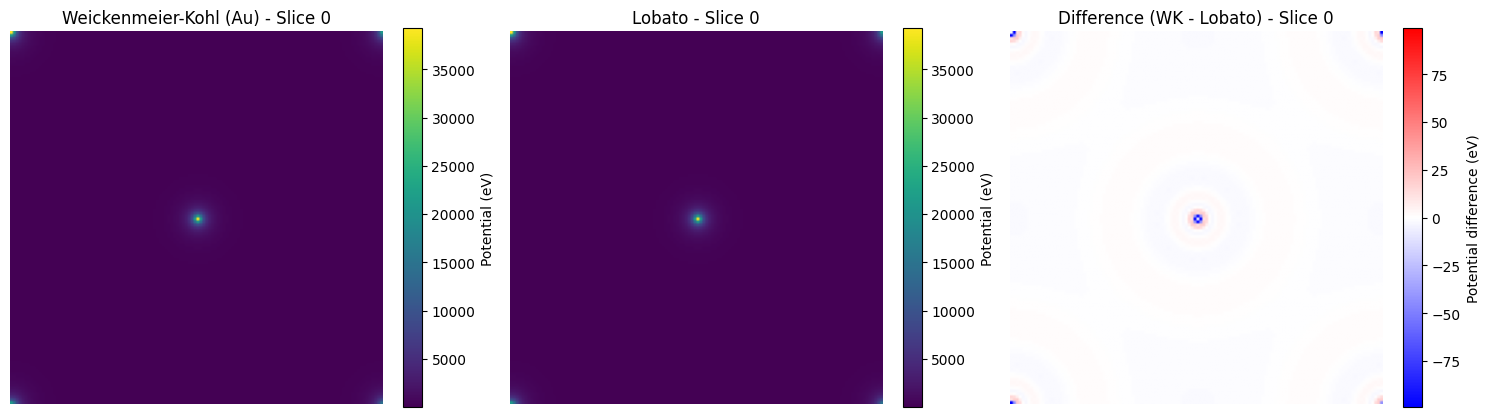

In [5]:
# Matplotlib needs CPU NumPy arrays; convert from CuPy explicitly.
pot_wk_cpu = cupy.asnumpy(pot_array_wk)
pot_lobato_cpu = cupy.asnumpy(pot_array_lobato)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5))

vmin = min(pot_wk_cpu.min(), pot_lobato_cpu.min())
vmax = max(pot_wk_cpu.max(), pot_lobato_cpu.max())

im0 = ax0.imshow(pot_wk_cpu[0], cmap='viridis', vmin=vmin, vmax=vmax)
ax0.set_title("Weickenmeier-Kohl (Au) - Slice 0")
ax0.axis("off")
fig.colorbar(im0, ax=ax0, fraction=0.046, label="Potential (eV)")

im1 = ax1.imshow(pot_lobato_cpu[0], cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title("Lobato - Slice 0")
ax1.axis("off")
fig.colorbar(im1, ax=ax1, fraction=0.046, label="Potential (eV)")

diff = pot_wk_cpu[0] - pot_lobato_cpu[0]
vabs = np.max(np.abs(diff))
im2 = ax2.imshow(diff, cmap='bwr', vmin=-vabs, vmax=vabs)
ax2.set_title("Difference (WK - Lobato) - Slice 0")
ax2.axis("off")
fig.colorbar(im2, ax=ax2, fraction=0.046, label="Potential difference (eV)")

plt.tight_layout()
plt.show()

## Potential generation and probe

In [6]:
wavelength = energy2wavelength(energy)
k0 = 2 * np.pi / wavelength

probe = abtem.PlaneWave(energy=energy)
probe.grid.match(potential_wk)

probe_array = probe.build(lazy=False).array

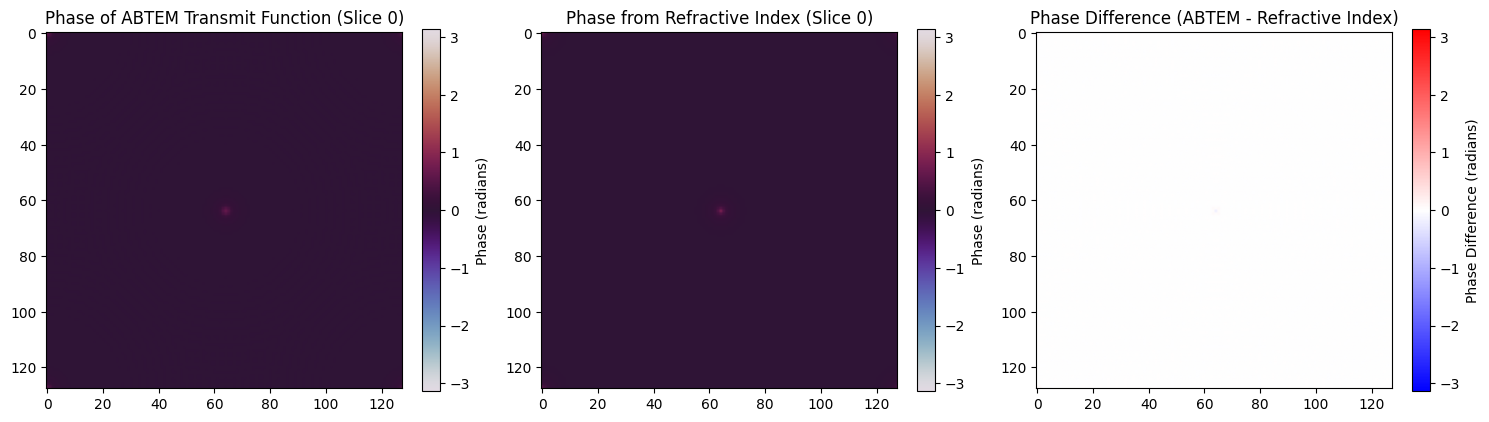

In [7]:
transmit = get_abtem_transmit(potential_lobato, energy)

transmit_0 = transmit[0].get()
# 1. Get the projected potential from abTEM (Units: Volt * Angstrom)
# potential_array has shape (N_slices, y, x)
V_projected = potential_lobato.build(lazy=False).array 
V_projected = cupy.asnumpy(V_projected)  # Convert to CPU for plotting if needed

# 2. Get the thickness of the slice (Units: Angstrom)
dz = potential_lobato.slice_thickness[0]

# 3. Rescale to get the effective 'average' potential in Volts
# This gives us the correct magnitude to plug into the relativistic formula
V_effective = np.array(V_projected[0] / dz)

# 4. Calculate the Refractive Index (n)
# n is unitless. It depends on V_effective (Volts) and Energy (eV)
n = electron_refractive_index(V_effective, energy)

# 5. Calculate the Transmission Function
# We multiply by dz again because the electron travels through this thickness
# Units: [1] * [Angstrom] / [Angstrom] = Dimensionless (Correct)
transmission_function = jnp.exp(1j * 2 * jnp.pi * (n - 1) * dz / wavelength)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
im1 = ax1.imshow(np.angle(transmit_0), cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax1.set_title("Phase of ABTEM Transmit Function (Slice 0)")
fig.colorbar(im1, ax=ax1, fraction=0.046, label="Phase (radians)")
im2 = ax2.imshow(np.angle(transmission_function), cmap='twilight', vmin=-np.pi, vmax=np.pi)
ax2.set_title("Phase from Refractive Index (Slice 0)")
fig.colorbar(im2, ax=ax2, fraction=0.046, label="Phase (radians)")

diff_phase = np.angle(transmit_0) - np.angle(transmission_function)
im3 = ax3.imshow(diff_phase, cmap='bwr', vmin=-np.pi, vmax=np.pi)
ax3.set_title("Phase Difference (ABTEM - Refractive Index)")
fig.colorbar(im3, ax=ax3, fraction=0.046, label="Phase Difference (radians)")

plt.tight_layout()
plt.show()



## Thickness sweep function

Run Fresnel multislice, angular spectrum multislice, and WPM through a thickness sweep.

In [8]:
def run_thickness_sweep(
    a_val,
    gpts=(128, 128),
    energy=300e3,
    n_cells=26,
    n_slices=lobato_n_slices,
    projection=lobato_projection,
):
    """Run Fresnel MS, Angular Spectrum MS, and WPM sweeps for given lattice parameter."""
    atoms_local = bulk("Au", "fcc", a=float(a_val), cubic=True)
    atoms_local.info["thermal_sigma"] = 0.0
    atoms_local.arrays["thermal_sigma"] = np.zeros(len(atoms_local))

    slice_dz = float(atoms_local.cell[2, 2] / n_slices)

    pot = abtem.Potential(
        atoms_local,
        gpts=gpts,
        slice_thickness=slice_dz,
        projection=projection,
        parametrization="lobato",
    )
    pot_array = jnp.array(cupy.asnumpy(pot.build(lazy=False).array / slice_dz))

    pw = abtem.PlaneWave(energy=energy)
    pw.grid.match(pot)
    psi0 = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
    sampling = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))

    fk = jnp.array(
        fresnel_propagation_kernel(gpts[0], gpts[1], sampling, z=slice_dz, energy=energy)
    )
    ak = jnp.array(
        angular_spectrum_propagation_kernel(gpts[0], gpts[1], sampling, z=slice_dz, energy=energy)
    )

    keys = ["ms_00", "ms_028", "as_00", "as_028", "wpm_00", "wpm_028"]
    results = {k: [] for k in keys}
    w_ms, w_as, w_wpm = psi0, psi0, psi0

    for i in range(n_cells):
        if i > 0:
            w_ms, _, _ = simulate_fresnel_as(pot_array, w_ms, fk, slice_dz, energy)
            w_as, _, _ = simulate_fresnel_as(pot_array, w_as, ak, slice_dz, energy)
            w_wpm, _, _ = simulate_wpm(pot_array, w_wpm, slice_dz, energy, sampling)

            w_ms = jnp.array(w_ms)
            w_as = jnp.array(w_as)
            w_wpm = jnp.array(w_wpm)

        results["ms_00"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 0))
        results["ms_028"].append(beam_amplitude_normalized(np.asarray(w_ms), 0, 28))
        results["as_00"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 0))
        results["as_028"].append(beam_amplitude_normalized(np.asarray(w_as), 0, 28))
        results["wpm_00"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 0))
        results["wpm_028"].append(beam_amplitude_normalized(np.asarray(w_wpm), 0, 28))

    beam_results = {k: jnp.array(v) for k, v in results.items()}
    exit_waves = {"ms": w_ms, "as": w_as, "wpm": w_wpm}
    return beam_results, exit_waves

## Run thickness sweep

In [9]:
results, sweep_exit = run_thickness_sweep(a_central, energy=energy, n_cells=len(n_cells_range))

print(
    f"Sweep complete: a = {a_central} Å, "
    f"Lobato {lobato_projection} projection, {lobato_n_slices} slices per cell"
)
print(f"[0,28] at 25 cells  —  MS: {results['ms_028'][-1]:.6f}  AS: {results['as_028'][-1]:.6f}  WPM: {results['wpm_028'][-1]:.6f}")

Sweep complete: a = 4.076 Å, Lobato finite projection, 128 slices per cell
[0,28] at 25 cells  —  MS: 0.014954  AS: 0.025076  WPM: 0.025004


## Extract results and paper references

In [10]:
x = np.array(list(n_cells_range), dtype=float)

# Simulation curves
measurements_multislice_0_0 = results['ms_00']
measurements_multislice_0_28 = results['ms_028']
measurements_as_0_0 = results['as_00']
measurements_as_0_28 = results['as_028']
measurements_wpm_0_0 = results['wpm_00']
measurements_wpm_0_28 = results['wpm_028']

# Paper reference curves
measurements_multislice_paper_0_0 = Beam_0_0_Au_Klein_Gordon_MS(x)
measurements_ms_paper_0_28 = Beam_0_28_Au_Klein_Gordon_MS(x)
measurements_fwd_ode_paper_0_28 = Beam_0_28_Au_Klein_Gordon_FWD(x)

## Forward KG verification methods

Run the remaining non-paraxial verification methods on the central-value potential, matching the paper's parameters.

In [11]:
# --- Prepare central-value potential for the forward KG / Bloch solvers ---
# Weickenmeier-Kohl parametrization, 128×128×128, no thermal motion.
a_paper = 4.076
atoms_central = bulk("Au", "fcc", a=a_paper, cubic=True)
atoms_central.info["thermal_sigma"] = 0.0
atoms_central.arrays["thermal_sigma"] = np.zeros(len(atoms_central))

n_slices_fwd = 128
slice_dz_fwd = float(atoms_central.cell[2, 2] / n_slices_fwd)

pot_fwd = abtem.Potential(
    atoms_central,
    gpts=(128, 128),
    slice_thickness=slice_dz_fwd,
    projection="finite",
    parametrization=wk_param,
)
pot_array_fwd = jnp.array(cupy.asnumpy(pot_fwd.build(lazy=False).array / slice_dz_fwd))

pw = abtem.PlaneWave(energy=energy)
pw.grid.match(pot_fwd)
psi0 = jnp.array(cupy.asnumpy(pw.build(lazy=False).array))
sampling_fwd = (float(pw.grid.sampling[0]), float(pw.grid.sampling[1]))

n_cells = len(n_cells_range)
n_cells_arr = np.arange(n_cells)

def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

print(
    f"Forward KG setup: {n_slices_fwd} slices per cell, "
    f"dz = {slice_dz_fwd:.4f} Å"
)

# --- Full KG ODE (2nd-order, non-parabolic, with backscattering) ---
print("\nFull KG ODE — d²ψ/dz² + (∇²⊥ + k₀²n²)ψ = 0 via diffrax...")
kg_ode_00, kg_ode_028 = [], []
w_kg = psi0
phi_kg = None

for i in tqdm(range(n_cells), desc="Full KG ODE sweep"):
    if i > 0:
        w_kg, phi_kg, _, _ = simulate_kg_ode_full(
            pot_array_fwd, w_kg, slice_dz_fwd, energy, sampling_fwd,
            initial_phi=phi_kg,
        )
        w_kg = jnp.array(w_kg)
    kg_ode_00.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 0))
    kg_ode_028.append(beam_amplitude_normalized(np.asarray(w_kg), 0, 28))

kg_ode_00 = np.array(kg_ode_00)
kg_ode_028 = np.array(kg_ode_028)

print(f"  [0,0] at {n_cells} cells: {kg_ode_00[-1]:.6f}")
print(f"  [0,28] at {n_cells} cells: {kg_ode_028[-1]:.6f}")
print(
    f"  RMSE vs paper: [0,0] {curve_rmse(kg_ode_00, measurements_multislice_paper_0_0):.6f}, "
    f"[0,28] {curve_rmse(kg_ode_028, measurements_fwd_ode_paper_0_28):.6f}"
)

# --- KG FWD all-beams (16384 beams, FFT + Lanczos) ---
print("\nKG FWD (all beams) — exp(i*dz*sqrt(M)) with all 128×128 beams...")
kg_all_amps, kg_all_bi, kg_fwd_exit_state = beam_amplitudes_fwd_direct_allbeams(
    pot_array_fwd,
    slice_dz_fwd,
    energy,
    sampling_fwd,
    n_cells_arr,
    (128, 128),
)
# Convert Fourier-space exit state to real-space exit wave
ny_fwd, nx_fwd = 128, 128
w_kg_fwd = ny_fwd * nx_fwd * np.fft.ifft2(kg_fwd_exit_state.reshape(ny_fwd, nx_fwd))

print(f"  Beams: {len(kg_all_bi)}")

kg_all_00 = kg_all_amps.get((0, 0), np.zeros(n_cells))
kg_all_028 = kg_all_amps.get((0, 28), np.zeros(n_cells))

print(f"  [0,0] at {n_cells} cells: {kg_all_00[-1]:.6f}")
print(f"  [0,28] at {n_cells} cells: {kg_all_028[-1]:.6f}")
print(
    f"  RMSE vs paper: [0,0] {curve_rmse(kg_all_00, measurements_multislice_paper_0_0):.6f}, "
    f"[0,28] {curve_rmse(kg_all_028, measurements_fwd_ode_paper_0_28):.6f}"
)

Forward KG setup: 128 slices per cell, dz = 0.0318 Å

Full KG ODE — d²ψ/dz² + (∇²⊥ + k₀²n²)ψ = 0 via diffrax...


Full KG ODE sweep:   0%|          | 0/26 [00:00<?, ?it/s]

  [0,0] at 26 cells: 0.798900
  [0,28] at 26 cells: 0.025177
  RMSE vs paper: [0,0] 0.008451, [0,28] 0.000777

KG FWD (all beams) — exp(i*dz*sqrt(M)) with all 128×128 beams...
  Beams: 16384
  [0,0] at 26 cells: 0.798885
  [0,28] at 26 cells: 0.024995
  RMSE vs paper: [0,0] 0.008502, [0,28] 0.000860


## Comparison plots

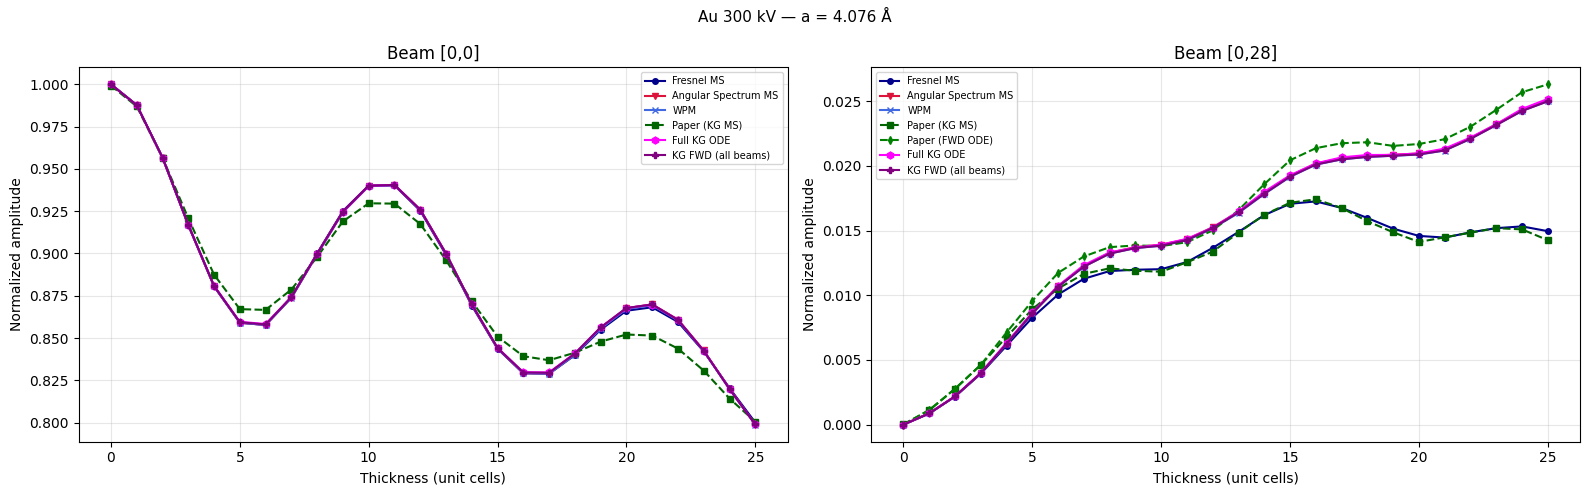

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# [0,0] beam
ax1.plot(x, measurements_multislice_0_0, "o-", label="Fresnel MS", color="darkblue", ms=4)
ax1.plot(x, measurements_as_0_0, "v-", label="Angular Spectrum MS", color="crimson", ms=4)
ax1.plot(x, measurements_wpm_0_0, "x-", label="WPM", color="royalblue", ms=5)
ax1.plot(x, measurements_multislice_paper_0_0, "s--", label="Paper (KG MS)", color="darkgreen", ms=4)
ax1.plot(x, kg_ode_00, "h-", label="Full KG ODE", color="magenta", ms=5)
ax1.plot(x, kg_all_00, "P-", label="KG FWD (all beams)", color="purple", ms=4)
ax1.set_xlabel("Thickness (unit cells)")
ax1.set_ylabel("Normalized amplitude")
ax1.set_title("Beam [0,0]")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=7)

# [0,28] beam
ax2.plot(x, measurements_multislice_0_28, "o-", label="Fresnel MS", color="darkblue", ms=4)
ax2.plot(x, measurements_as_0_28, "v-", label="Angular Spectrum MS", color="crimson", ms=4)
ax2.plot(x, measurements_wpm_0_28, "x-", label="WPM", color="royalblue", ms=5)
ax2.plot(x, measurements_ms_paper_0_28, "s--", label="Paper (KG MS)", color="darkgreen", ms=4)
ax2.plot(x, measurements_fwd_ode_paper_0_28, "d--", label="Paper (FWD ODE)", color="green", ms=4)
ax2.plot(x, kg_ode_028, "h-", label="Full KG ODE", color="magenta", ms=5)
ax2.plot(x, kg_all_028, "P-", label="KG FWD (all beams)", color="purple", ms=4)
ax2.set_xlabel("Thickness (unit cells)")
ax2.set_ylabel("Normalized amplitude")
ax2.set_title("Beam [0,28]")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=7)

fig.suptitle(f"Au 300 kV \u2014 a = {a_central} \u00c5", fontsize=11)
plt.tight_layout()
plt.show()

Saved to /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/Au_beam_amplitudes.pdf and ./Au_beam_amplitudes.png


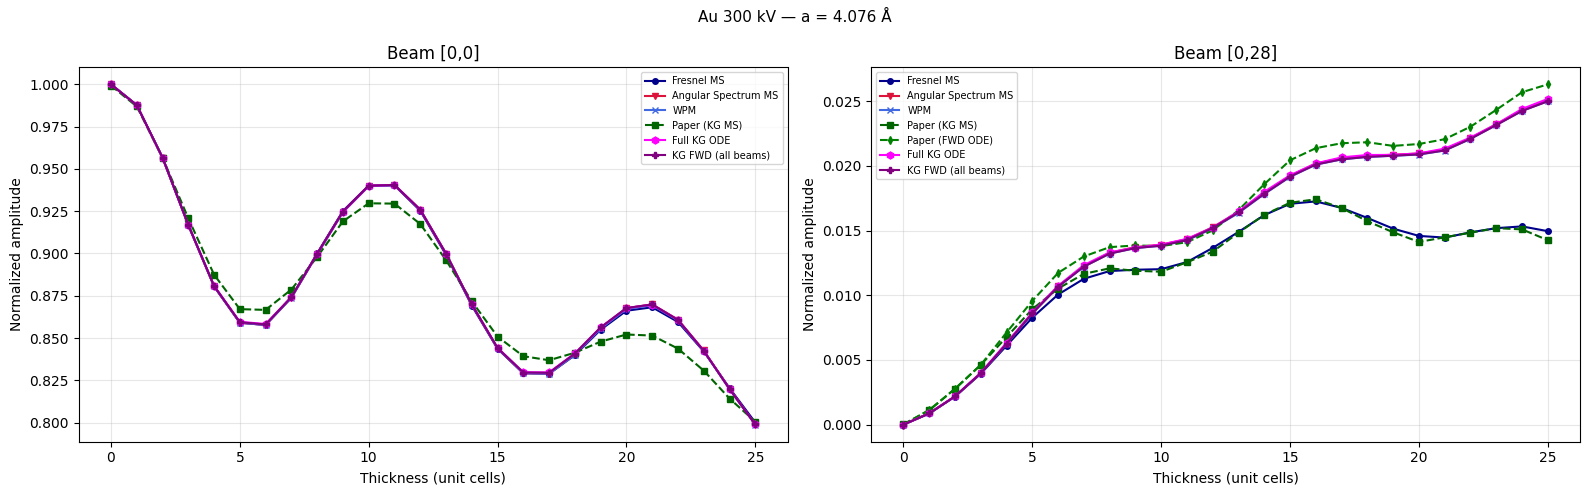


RMSE Summary — Beam amplitudes vs paper reference curves
Method                      [0,0] RMSE    [0,28] RMSE
-----------------------------------------------------
Fresnel MS                    0.008174       0.005023
Angular Spectrum MS           0.008582       0.000815
WPM                           0.008401       0.000865
Full KG ODE                   0.008451       0.000777
KG FWD (all beams)            0.008502       0.000860


In [13]:
# ── Publication-quality figure export and RMSE summary table ──

import os

# --- Re-create and save figure as PDF ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(x, measurements_multislice_0_0, "o-", label="Fresnel MS", color="darkblue", ms=4)
ax1.plot(x, measurements_as_0_0, "v-", label="Angular Spectrum MS", color="crimson", ms=4)
ax1.plot(x, measurements_wpm_0_0, "x-", label="WPM", color="royalblue", ms=5)
ax1.plot(x, measurements_multislice_paper_0_0, "s--", label="Paper (KG MS)", color="darkgreen", ms=4)
ax1.plot(x, kg_ode_00, "h-", label="Full KG ODE", color="magenta", ms=5)
ax1.plot(x, kg_all_00, "P-", label="KG FWD (all beams)", color="purple", ms=4)
ax1.set_xlabel("Thickness (unit cells)")
ax1.set_ylabel("Normalized amplitude")
ax1.set_title("Beam [0,0]")
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=7)

ax2.plot(x, measurements_multislice_0_28, "o-", label="Fresnel MS", color="darkblue", ms=4)
ax2.plot(x, measurements_as_0_28, "v-", label="Angular Spectrum MS", color="crimson", ms=4)
ax2.plot(x, measurements_wpm_0_28, "x-", label="WPM", color="royalblue", ms=5)
ax2.plot(x, measurements_ms_paper_0_28, "s--", label="Paper (KG MS)", color="darkgreen", ms=4)
ax2.plot(x, measurements_fwd_ode_paper_0_28, "d--", label="Paper (FWD ODE)", color="green", ms=4)
ax2.plot(x, kg_ode_028, "h-", label="Full KG ODE", color="magenta", ms=5)
ax2.plot(x, kg_all_028, "P-", label="KG FWD (all beams)", color="purple", ms=4)
ax2.set_xlabel("Thickness (unit cells)")
ax2.set_ylabel("Normalized amplitude")
ax2.set_title("Beam [0,28]")
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=7)

fig.suptitle(f"Au 300 kV — a = {a_central} Å", fontsize=11)
plt.tight_layout()

out_dir = os.path.join(os.path.dirname(os.path.abspath(".")), "Paper", "figures")
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "Au_beam_amplitudes.pdf"), dpi=300, bbox_inches="tight")
fig.savefig("Au_beam_amplitudes.png", dpi=300, bbox_inches="tight")
print(f"Saved to {out_dir}/Au_beam_amplitudes.pdf and ./Au_beam_amplitudes.png")
plt.show()

# --- RMSE summary table ---
print("\n" + "=" * 70)
print("RMSE Summary — Beam amplitudes vs paper reference curves")
print("=" * 70)
print(f"{'Method':<25s} {'[0,0] RMSE':>12s} {'[0,28] RMSE':>14s}")
print("-" * 53)

def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

methods_00 = {
    "Fresnel MS": measurements_multislice_0_0,
    "Angular Spectrum MS": measurements_as_0_0,
    "WPM": measurements_wpm_0_0,
    "Full KG ODE": kg_ode_00,
    "KG FWD (all beams)": kg_all_00,
}

methods_028 = {
    "Fresnel MS": measurements_multislice_0_28,
    "Angular Spectrum MS": measurements_as_0_28,
    "WPM": measurements_wpm_0_28,
    "Full KG ODE": kg_ode_028,
    "KG FWD (all beams)": kg_all_028,
}

for name in methods_00:
    r00 = curve_rmse(methods_00[name], measurements_multislice_paper_0_0)
    r028 = curve_rmse(methods_028[name], measurements_fwd_ode_paper_0_28)
    print(f"{name:<25s} {r00:>12.6f} {r028:>14.6f}")

## Method timings

Time each propagation method independently over the full thickness sweep.

In [14]:
# --- Time each propagation method over the full sweep ---

_gpts = (128, 128)
_n_cells = len(n_cells_range)

# -- Lobato potential (Fresnel, AS, WPM) --
_atoms_l = bulk("Au", "fcc", a=a_central, cubic=True)
_atoms_l.info["thermal_sigma"] = 0.0
_atoms_l.arrays["thermal_sigma"] = np.zeros(len(_atoms_l))
_slice_dz_l = float(_atoms_l.cell[2, 2] / lobato_n_slices)

_pot_l = abtem.Potential(
    _atoms_l, gpts=_gpts, slice_thickness=_slice_dz_l,
    projection=lobato_projection, parametrization="lobato",
)
_pot_arr_l = jnp.array(cupy.asnumpy(_pot_l.build(lazy=False).array / _slice_dz_l))

_pw_l = abtem.PlaneWave(energy=energy)
_pw_l.grid.match(_pot_l)
_psi0_l = jnp.array(cupy.asnumpy(_pw_l.build(lazy=False).array))
_samp_l = (float(_pw_l.grid.sampling[0]), float(_pw_l.grid.sampling[1]))

_fk = jnp.array(fresnel_propagation_kernel(_gpts[0], _gpts[1], _samp_l, z=_slice_dz_l, energy=energy))
_ak = jnp.array(angular_spectrum_propagation_kernel(_gpts[0], _gpts[1], _samp_l, z=_slice_dz_l, energy=energy))

# Fresnel MS
_w = _psi0_l
t0 = perf_counter()
for _i in range(_n_cells):
    if _i > 0:
        _w, _, _ = simulate_fresnel_as(_pot_arr_l, _w, _fk, _slice_dz_l, energy)
        _w = jnp.array(_w)
fresnel_elapsed = perf_counter() - t0

# Angular Spectrum MS
_w = _psi0_l
t0 = perf_counter()
for _i in range(_n_cells):
    if _i > 0:
        _w, _, _ = simulate_fresnel_as(_pot_arr_l, _w, _ak, _slice_dz_l, energy)
        _w = jnp.array(_w)
as_elapsed = perf_counter() - t0

# WPM
_w = _psi0_l
t0 = perf_counter()
for _i in range(_n_cells):
    if _i > 0:
        _w, _, _ = simulate_wpm(_pot_arr_l, _w, _slice_dz_l, energy, _samp_l)
        _w = jnp.array(_w)
wpm_elapsed = perf_counter() - t0

# -- WK potential (Full KG ODE, KG FWD) --
_w = psi0
_phi = None
t0 = perf_counter()
for _i in range(_n_cells):
    if _i > 0:
        _w, _phi, _, _ = simulate_kg_ode_full(
            pot_array_fwd, _w, slice_dz_fwd, energy, sampling_fwd,
            initial_phi=_phi,
        )
        _w = jnp.array(_w)
kg_ode_elapsed = perf_counter() - t0

t0 = perf_counter()
_, _, _ = beam_amplitudes_fwd_direct_allbeams(
    pot_array_fwd, slice_dz_fwd, energy, sampling_fwd,
    n_cells_arr, (128, 128),
)
kg_fwd_elapsed = perf_counter() - t0

# --- Summary ---
print(f"{'Method':<25s} {'Time (s)':>10s}")
print("-" * 37)
print(f"{'Fresnel MS':<25s} {fresnel_elapsed:>10.2f}")
print(f"{'Angular Spectrum MS':<25s} {as_elapsed:>10.2f}")
print(f"{'WPM':<25s} {wpm_elapsed:>10.2f}")
print(f"{'Full KG ODE':<25s} {kg_ode_elapsed:>10.2f}")
print(f"{'KG FWD (all beams)':<25s} {kg_fwd_elapsed:>10.2f}")

Method                      Time (s)
-------------------------------------
Fresnel MS                      5.60
Angular Spectrum MS             5.28
WPM                            44.07
Full KG ODE                    63.87
KG FWD (all beams)             24.37


## Exit Wave Comparison

Compare the final exit waves (at maximum thickness = 25 unit cells) for each propagation method.  The Fresnel MS, Angular Spectrum MS, and WPM exit waves are reused from the thickness sweep; the KG ODE and KG FWD exit waves are reused from the forward KG verification cell.

In [15]:
# --- Reuse exit waves already computed in earlier cells ---
# Fresnel MS, Angular Spectrum MS, WPM: from run_thickness_sweep (sweep_exit)
# KG ODE: w_kg from the KG verification sweep
# KG FWD: w_kg_fwd from beam_amplitudes_fwd_direct_allbeams exit state

w_exit_fresnel = sweep_exit["ms"]
w_exit_as = sweep_exit["as"]
w_exit_wpm = sweep_exit["wpm"]
w_exit_kg = w_kg
w_exit_fwd = w_kg_fwd

n_cells_exit = len(n_cells_range) - 1

print(f"Exit waves reused from earlier cells ({n_cells_exit} unit cells).")
print(f"  Fresnel MS:          mean |\u03c8| = {float(jnp.mean(jnp.abs(w_exit_fresnel))):.6f}")
print(f"  Angular Spectrum MS: mean |\u03c8| = {float(jnp.mean(jnp.abs(w_exit_as))):.6f}")
print(f"  WPM:                 mean |\u03c8| = {float(jnp.mean(jnp.abs(w_exit_wpm))):.6f}")
print(f"  KG ODE:              mean |\u03c8| = {float(jnp.mean(jnp.abs(w_exit_kg))):.6f}")
print(f"  KG FWD:              mean |\u03c8| = {float(np.mean(np.abs(w_exit_fwd))):.6f}")

Exit waves reused from earlier cells (25 unit cells).
  Fresnel MS:          mean |ψ| = 0.930405
  Angular Spectrum MS: mean |ψ| = 0.930295
  WPM:                 mean |ψ| = 0.930426
  KG ODE:              mean |ψ| = 0.930389
  KG FWD:              mean |ψ| = 0.930322


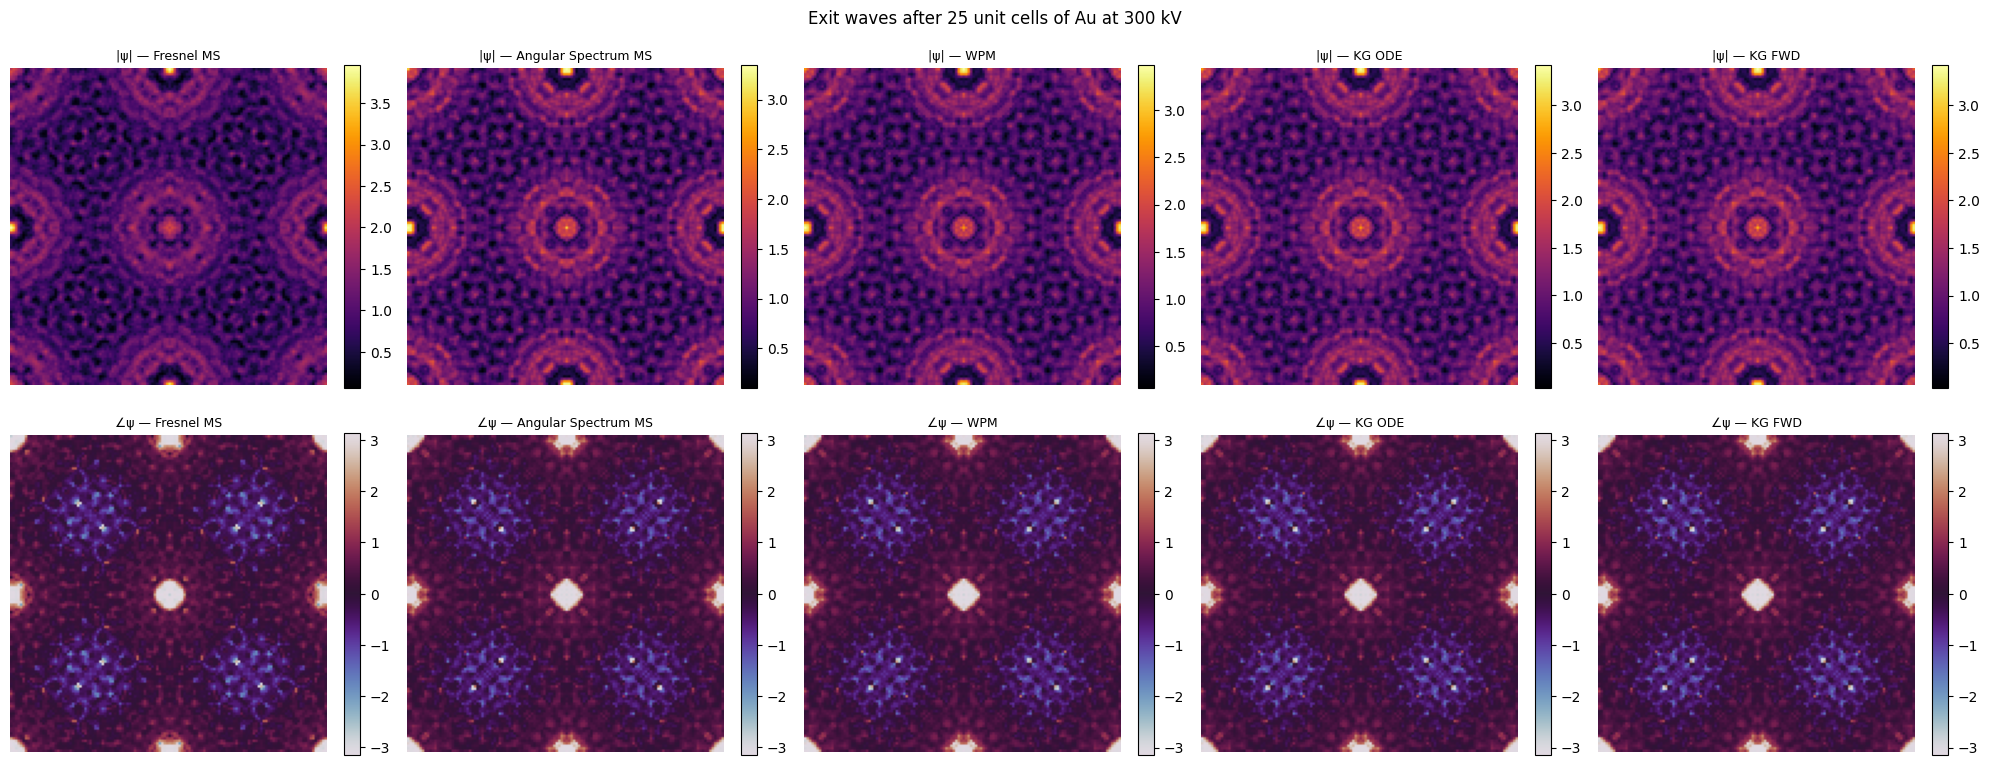

In [16]:
# --- Plot exit wave amplitudes ---
exit_waves = {
    "Fresnel MS": np.asarray(w_exit_fresnel),
    "Angular Spectrum MS": np.asarray(w_exit_as),
    "WPM": np.asarray(w_exit_wpm),
    "KG ODE": np.asarray(w_exit_kg),
    "KG FWD": np.asarray(w_exit_fwd),
}

n_methods = len(exit_waves)
fig, axes = plt.subplots(2, n_methods, figsize=(4 * n_methods, 8))

# Row 0: amplitude, Row 1: phase
for j, (name, psi) in enumerate(exit_waves.items()):
    amp = np.abs(psi)
    phase = np.angle(psi)

    im_amp = axes[0, j].imshow(amp, cmap="inferno")
    axes[0, j].set_title(f"|\u03c8| \u2014 {name}", fontsize=9)
    axes[0, j].axis("off")
    fig.colorbar(im_amp, ax=axes[0, j], fraction=0.046)

    im_ph = axes[1, j].imshow(phase, cmap="twilight", vmin=-np.pi, vmax=np.pi)
    axes[1, j].set_title(f"\u2220\u03c8 \u2014 {name}", fontsize=9)
    axes[1, j].axis("off")
    fig.colorbar(im_ph, ax=axes[1, j], fraction=0.046)

fig.suptitle(f"Exit waves after {n_cells_exit} unit cells of Au at 300 kV", fontsize=12)
plt.tight_layout()
plt.show()

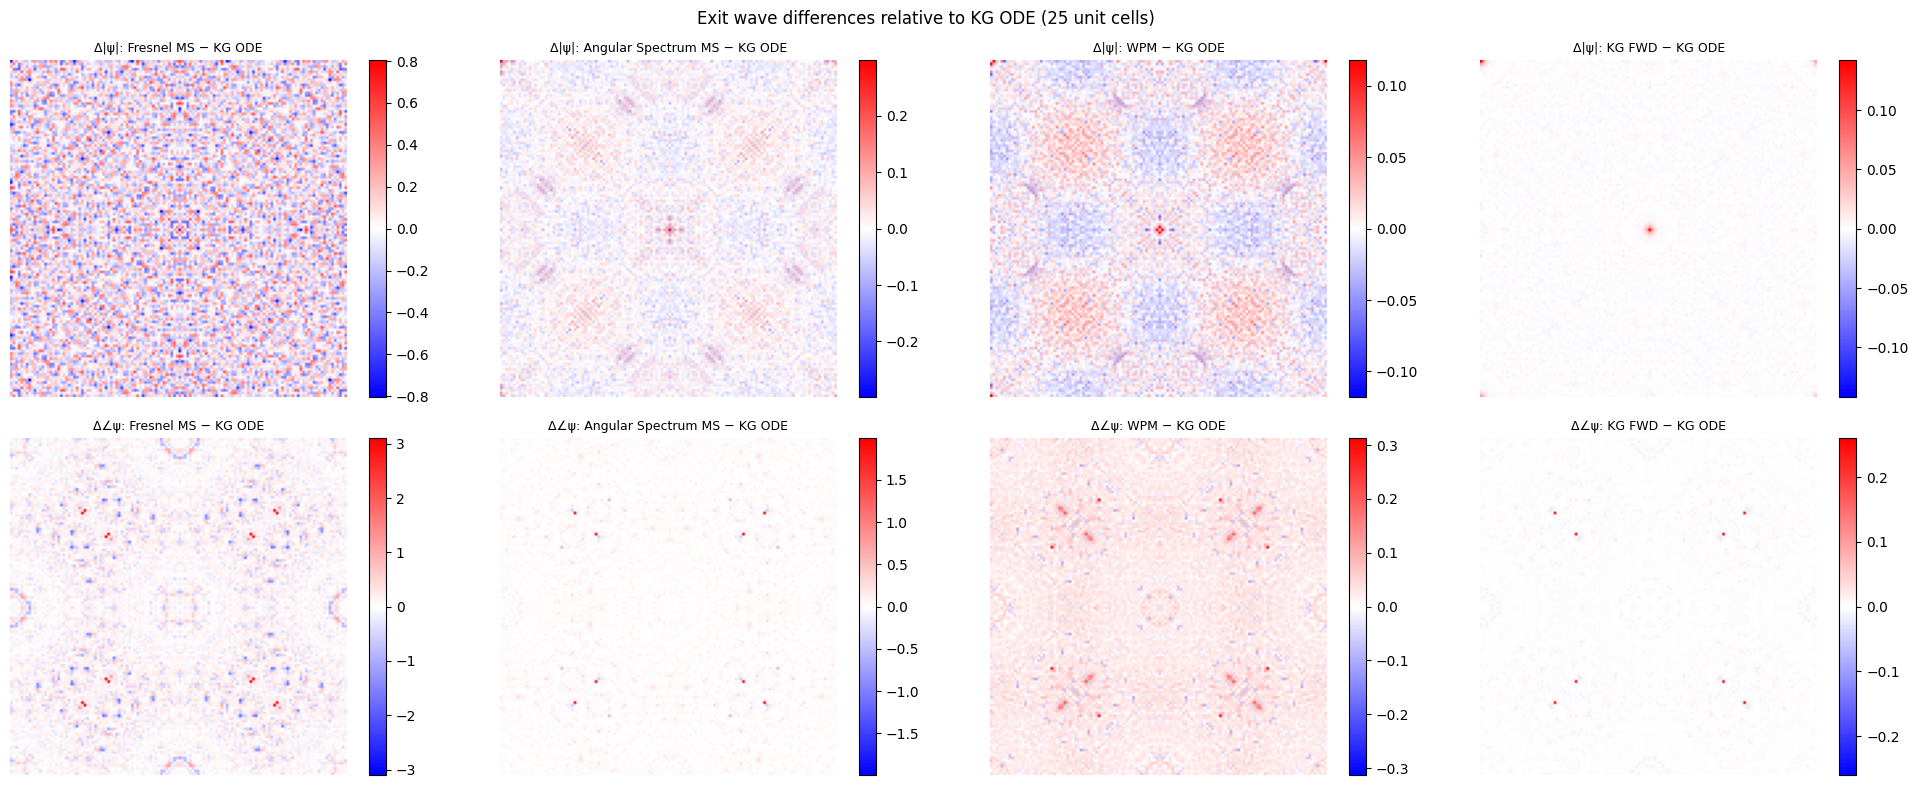


Method                        Amp RMSE   Phase RMSE (rad)
---------------------------------------------------------
Fresnel MS                    0.204412           0.281905
Angular Spectrum MS           0.028947           0.065397
WPM                           0.018356           0.034032
KG FWD                        0.003136           0.006624


In [17]:
# --- Pairwise difference maps (amplitude and phase) relative to KG ODE ---
ref_name = "KG ODE"
ref_psi = exit_waves[ref_name]
compare_methods = {k: v for k, v in exit_waves.items() if k != ref_name}

n_comp = len(compare_methods)
fig, axes = plt.subplots(2, n_comp, figsize=(5 * n_comp, 8))

for j, (name, psi) in enumerate(compare_methods.items()):
    amp_diff = np.abs(psi) - np.abs(ref_psi)
    phase_diff = np.angle(psi * np.conj(ref_psi))  # wrapped phase difference

    vabs_amp = np.max(np.abs(amp_diff))
    im_amp = axes[0, j].imshow(amp_diff, cmap="bwr", vmin=-vabs_amp, vmax=vabs_amp)
    axes[0, j].set_title(f"Δ|ψ|: {name} − {ref_name}", fontsize=9)
    axes[0, j].axis("off")
    fig.colorbar(im_amp, ax=axes[0, j], fraction=0.046)

    vabs_ph = np.max(np.abs(phase_diff))
    im_ph = axes[1, j].imshow(phase_diff, cmap="bwr", vmin=-vabs_ph, vmax=vabs_ph)
    axes[1, j].set_title(f"Δ∠ψ: {name} − {ref_name}", fontsize=9)
    axes[1, j].axis("off")
    fig.colorbar(im_ph, ax=axes[1, j], fraction=0.046)

fig.suptitle(f"Exit wave differences relative to {ref_name} ({n_cells_exit} unit cells)", fontsize=12)
plt.tight_layout()
plt.show()

# Print RMSE summary
print(f"\n{'Method':<25s} {'Amp RMSE':>12s} {'Phase RMSE (rad)':>18s}")
print("-" * 57)
for name, psi in compare_methods.items():
    amp_rmse = np.sqrt(np.mean((np.abs(psi) - np.abs(ref_psi))**2))
    phase_diff = np.angle(psi * np.conj(ref_psi))
    phase_rmse = np.sqrt(np.mean(phase_diff**2))
    print(f"{name:<25s} {amp_rmse:>12.6f} {phase_rmse:>18.6f}")

In [18]:
# Full KG regression check using the restored second-order solver.
a_regression = 4.076
atoms_regression = bulk("Au", "fcc", a=a_regression, cubic=True)
atoms_regression.info["thermal_sigma"] = 0.0
atoms_regression.arrays["thermal_sigma"] = np.zeros(len(atoms_regression))

n_slices_regression = 128
slice_dz_regression = float(atoms_regression.cell[2, 2] / n_slices_regression)

pot_regression = abtem.Potential(
    atoms_regression,
    gpts=(128, 128),
    slice_thickness=slice_dz_regression,
    projection="finite",
    parametrization=wk_param,
)
pot_array_regression = jnp.array(
    cupy.asnumpy(pot_regression.build(lazy=False).array / slice_dz_regression)
)

pw_regression = abtem.PlaneWave(energy=energy)
pw_regression.grid.match(pot_regression)
psi0_regression = jnp.array(cupy.asnumpy(pw_regression.build(lazy=False).array))
sampling_regression = (
    float(pw_regression.grid.sampling[0]),
    float(pw_regression.grid.sampling[1]),
)

x_regression = np.array(list(n_cells_range), dtype=float)
paper_00_regression = Beam_0_0_Au_Klein_Gordon_MS(x_regression)
paper_028_regression = Beam_0_28_Au_Klein_Gordon_FWD(x_regression)

def curve_rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

kg_ode_00_regression = []
kg_ode_028_regression = []
w_kg_regression = psi0_regression
phi_kg_regression = None

for idx in tqdm(range(len(n_cells_range)), desc="Notebook KG regression"):
    if idx > 0:
        w_kg_regression, phi_kg_regression, _, _ = simulate_kg_ode_full(
            pot_array_regression,
            w_kg_regression,
            slice_dz_regression,
            energy,
            sampling_regression,
            initial_phi=phi_kg_regression,
        )
        w_kg_regression = jnp.array(w_kg_regression)
    kg_ode_00_regression.append(
        beam_amplitude_normalized(np.asarray(w_kg_regression), 0, 0)
    )
    kg_ode_028_regression.append(
        beam_amplitude_normalized(np.asarray(w_kg_regression), 0, 28)
    )

kg_ode_00_regression = np.array(kg_ode_00_regression)
kg_ode_028_regression = np.array(kg_ode_028_regression)

kg_all_regression, _, _ = beam_amplitudes_fwd_direct_allbeams(
    pot_array_regression,
    slice_dz_regression,
    energy,
    sampling_regression,
    np.arange(len(n_cells_range)),
    (128, 128),
)
kg_all_00_regression = kg_all_regression.get((0, 0), np.zeros(len(n_cells_range)))
kg_all_028_regression = kg_all_regression.get((0, 28), np.zeros(len(n_cells_range)))

print("Notebook KG regression summary")
print(f"  Full KG ODE   RMSE [0,0]: {curve_rmse(kg_ode_00_regression, paper_00_regression):.6f}")
print(f"  Full KG ODE   RMSE [0,28]: {curve_rmse(kg_ode_028_regression, paper_028_regression):.6f}")
print(f"  KG FWD beams  RMSE [0,0]: {curve_rmse(kg_all_00_regression, paper_00_regression):.6f}")
print(f"  KG FWD beams  RMSE [0,28]: {curve_rmse(kg_all_028_regression, paper_028_regression):.6f}")

kg_regression_summary = {
    "kg_ode_00_rmse": curve_rmse(kg_ode_00_regression, paper_00_regression),
    "kg_ode_028_rmse": curve_rmse(kg_ode_028_regression, paper_028_regression),
    "kg_fwd_00_rmse": curve_rmse(kg_all_00_regression, paper_00_regression),
    "kg_fwd_028_rmse": curve_rmse(kg_all_028_regression, paper_028_regression),
    "kg_ode_00_final": float(kg_ode_00_regression[-1]),
    "kg_ode_028_final": float(kg_ode_028_regression[-1]),
    "kg_fwd_00_final": float(np.asarray(kg_all_00_regression)[-1]),
    "kg_fwd_028_final": float(np.asarray(kg_all_028_regression)[-1]),
}
kg_regression_summary

Notebook KG regression:   0%|          | 0/26 [00:00<?, ?it/s]

Notebook KG regression summary
  Full KG ODE   RMSE [0,0]: 0.008451
  Full KG ODE   RMSE [0,28]: 0.000777
  KG FWD beams  RMSE [0,0]: 0.008502
  KG FWD beams  RMSE [0,28]: 0.000860


{'kg_ode_00_rmse': 0.00845085462620552,
 'kg_ode_028_rmse': 0.0007770757389016894,
 'kg_fwd_00_rmse': 0.008501716992983669,
 'kg_fwd_028_rmse': 0.0008599363690737378,
 'kg_ode_00_final': 0.7988999533301807,
 'kg_ode_028_final': 0.025176985887264164,
 'kg_fwd_00_final': 0.7988853509836934,
 'kg_fwd_028_final': 0.02499504906822881}